<a href="https://colab.research.google.com/github/engineerchacon/Procesamiento-de-Lenguaje-Natural/blob/main/Ejercicio_Clasificaci%C3%B3n_de_texto_Armando_Chac%C3%B3n_Terrazas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Ejercicio - Clasificación de texto-Armando Chacón Terrazas**

# **Celda 1: Conexión a Drive e Importación de Herramientas**

In [1]:
# 1. Conectamos Google Colab con nuestro Google Drive para poder leer el archivo
from google.colab import drive
drive.mount('/content/drive')

# 2. Importamos las librerías que nos ayudarán a trabajar
import pandas as pd        # Pandas es como un Excel vitaminado; nos permite ver y manipular tablas de datos.
import re                  # 're' significa Expresiones Regulares; sirve para buscar y reemplazar patrones de texto (ej. etiquetas HTML).
import string              # Contiene una lista de todos los signos de puntuación estándar.
import nltk                # NLTK es la caja de herramientas principal para Procesamiento de Lenguaje Natural.
from nltk.corpus import stopwords # Importamos específicamente el diccionario de palabras vacías (stopwords).

# 3. Descargamos los recursos necesarios de NLTK
# Descargamos el paquete de 'stopwords' para tener la lista de palabras vacías en inglés.
nltk.download('stopwords')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

# **Celda 2: Carga y Exploración de Datos**

In [2]:
# Guardamos la ruta exacta donde está guardado nuestro archivo en Drive
ruta_archivo = '/content/drive/MyDrive/UACJ/Procesamiento de lenguaje natural/IMDB Reviews.csv'

# Usamos la función 'read_csv' de Pandas para leer el archivo.
# Esto convierte nuestro archivo de texto en una tabla manejable llamada DataFrame (df).
df = pd.read_csv(ruta_archivo)

# Mostramos en pantalla las primeras 5 filas para comprobar que los datos se cargaron correctamente.
df.head()

,review,sentimento
0,One of the other reviewers has mentioned that ...,1
1,A wonderful little production. <br /><br />The...,1
2,I thought this was a wonderful way to spend ti...,1
3,Basically there's a family where a little boy ...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",1


# **Celda 3: Limpieza y Normalización del Texto**

In [3]:
# Creamos nuestro conjunto de palabras vacías (stopwords)
palabras_vacias_ingles = set(stopwords.words('english'))

def limpiar_texto_imdb(texto):
    """
    Función para limpiar reseñas de películas paso a paso.
    """

    # PASO 1: Minúsculas
    texto = texto.lower()

    # PASO 2: Quitar etiquetas HTML (ej. <br />)
    texto = re.sub(r'<.*?>', ' ', texto)

    # PASO 3: Quitar signos de puntuación
    texto = re.sub(r'[%s]' % re.escape(string.punctuation), '', texto)

    # PASO 4: Quitar números
    texto = re.sub(r'\d+', '', texto)

    # PASO 5: Quitar palabras vacías (Stopwords) usando un ciclo 'for' clásico
    # Primero, cortamos el texto en palabras individuales
    palabras = texto.split()

    # Creamos una 'caja vacía' (lista) para guardar solo las palabras que nos sirven
    palabras_limpias = []

    # Revisamos una por una las palabras del texto original
    for palabra in palabras:
        # Si la palabra NO está en la lista de palabras inútiles (stopwords)...
        if palabra not in palabras_vacias_ingles:
            # ... entonces la guardamos en nuestra caja de palabras limpias
            palabras_limpias.append(palabra)

    # PASO 6: Volver a unir las palabras limpias con un espacio entre ellas
    texto_final = ' '.join(palabras_limpias)

    return texto_final

# Ejecutamos la limpieza en toda la columna
df['review_limpio'] = df['review'].apply(limpiar_texto_imdb)

# Verificamos el resultado
print("--- ANTES DE LA LIMPIEZA ---")
print(df['review'].iloc[0][:500])

print("\n--- DESPUÉS DE LA LIMPIEZA ---")
print(df['review_limpio'].iloc[0][:500])

--- ANTES DE LA LIMPIEZA ---
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ

--- DESPUÉS DE LA LIMPIEZA ---
one reviewers mentioned watching oz episode youll hooked right exactly happened first thing struck oz brutality unflinching scenes violence set right word go trust show faint hearted timid show pulls punches regards drugs sex violence hardcore classic use word called oz nickname given oswald maximum security state penitentary focuses mainly emerald city experimental section prison cells glass fronts face inwards privacy high agenda em

# **Realizar un análisis exploratorio de datos.**

# **Celda 4: Balance de Clases**

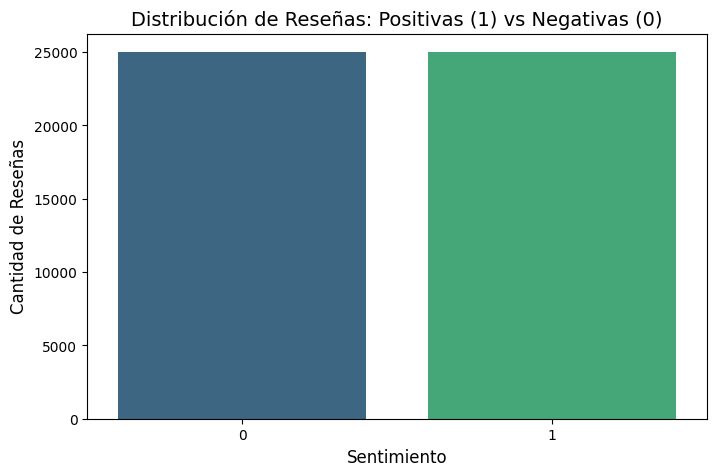

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

def graficar_balance(dataframe):
    """
    Revisamos si tenemos la misma cantidad de reseñas positivas y negativas.
    Usamos la columna correcta 'sentimento'
    """
    plt.figure(figsize=(8, 5))

    # Se agregó hue='sentimento' y legend=False para cumplir con la nueva versión de Seaborn
    sns.countplot(data=dataframe, x='sentimento', hue='sentimento', palette='viridis', legend=False)

    plt.title('Distribución de Reseñas: Positivas (1) vs Negativas (0)', fontsize=14)
    plt.xlabel('Sentimiento', fontsize=12)
    plt.ylabel('Cantidad de Reseñas', fontsize=12)

    plt.show()

# Ejecutamos la gráfica
graficar_balance(df)

# **Celda 5: Nubes de Palabras y Frecuencias**

--- NUBE DE PALABRAS ---


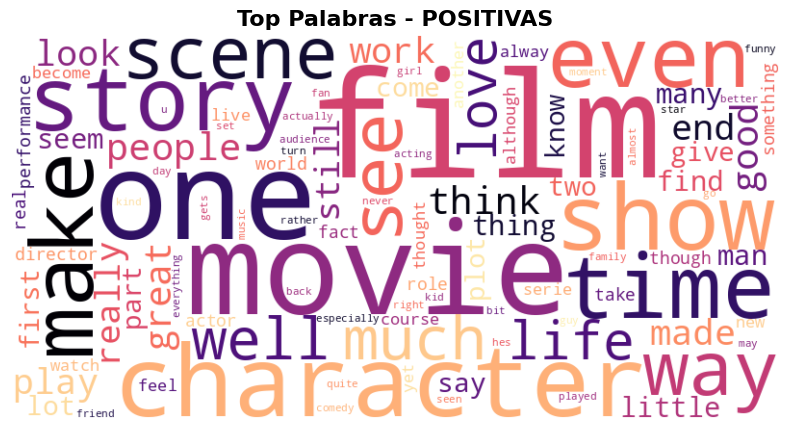

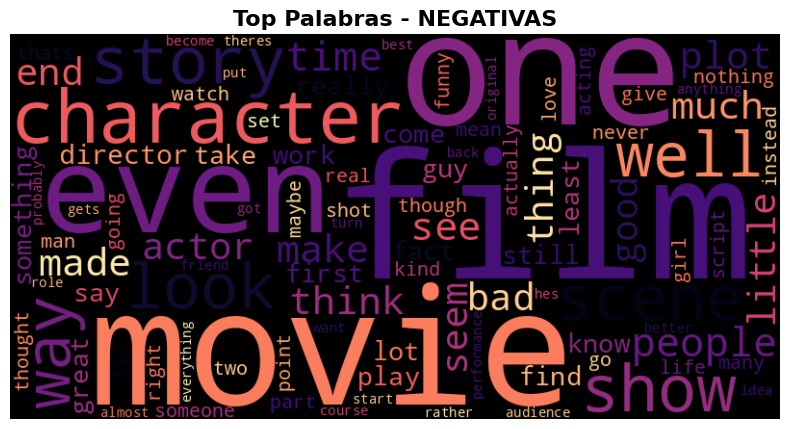

In [5]:
from wordcloud import WordCloud
from collections import Counter

# Separamos los textos usando la columna correcta 'sentimento'
resenas_positivas = df[df['sentimento'] == 1]['review_limpio']
resenas_negativas = df[df['sentimento'] == 0]['review_limpio']

def generar_nube_palabras(textos, titulo, color_fondo):
    """Genera una imagen visual de las palabras más frecuentes."""
    texto_completo = ' '.join(textos)
    nube = WordCloud(width=800, height=400, background_color=color_fondo,
                     colormap='magma', max_words=100).generate(texto_completo)

    plt.figure(figsize=(10, 5))
    plt.imshow(nube, interpolation='bilinear')
    plt.axis('off')
    plt.title(titulo, fontsize=16, fontweight='bold')
    plt.show()

# Generamos las nubes
print("--- NUBE DE PALABRAS ---")
generar_nube_palabras(resenas_positivas, "Top Palabras - POSITIVAS", 'white')
generar_nube_palabras(resenas_negativas, "Top Palabras - NEGATIVAS", 'black')

# **Utilizar Bag of Words y TF-IDF para transformar los comentarios que están en la columna ‘Review’ a vectores.**

# **Utiliza una partición (train_test_split) 80-20 para los conjuntos train y test.**

# **Celda 6: Vectorización y Partición Estratificada**

In [6]:
# VECTORIZACIÓN Y PARTICIÓN ESTRATIFICADA

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split

# Variables base
X_texto = df['review_limpio']
y = df['sentimento']

# --- VECTORIZACIÓN ---
# Usamos max_features para filtrar palabras irrelevantes y reducir la dimensionalidad.
vectorizador_bow = CountVectorizer(max_features=5000)
X_bow = vectorizador_bow.fit_transform(X_texto)

vectorizador_tfidf = TfidfVectorizer(max_features=5000)
X_tfidf = vectorizador_tfidf.fit_transform(X_texto)

# --- PARTICIÓN ESTRATIFICADA (80-20) ---
# Añadimos 'stratify=y'.
# Esto garantiza que si el dataset original es 50/50, el set de examen también lo sea.
X_train_bow, X_test_bow, y_train, y_test = train_test_split(
    X_bow, y, test_size=0.2, random_state=42, stratify=y
)

X_train_tfidf, X_test_tfidf, _, _ = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Partición completada. Datos de entrenamiento: {X_train_tfidf.shape[0]}")
print(f"Estratificación aplicada: Las proporciones de clases se mantienen en Train y Test.")

Partición completada. Datos de entrenamiento: 40000
Estratificación aplicada: Las proporciones de clases se mantienen en Train y Test.


# **Entrenar los modelos Multinomial Naive Bayes, SVM, Random Forest, kNN y Logistic Regression**
# **Mostrar la matriz de confusión.**
# **Aplicar las métricas Precision, Recall, F1-Score (por cada una de las clases), Accuracy y AUC-ROC.**


# **Celda 7: Función de Evaluación**

In [7]:
# FUNCIÓN DE EVALUACIÓN MULTI-MÉTRICA

from sklearn.metrics import classification_report, ConfusionMatrixDisplay, roc_auc_score, accuracy_score
import matplotlib.pyplot as plt

def evaluar_modelo_clase(modelo, nombre_modelo, X_train, X_test, y_train, y_test):
    """
    Evalúa el modelo aplicando las métricas Precision, Recall, F1, Accuracy y AUC-ROC.
    """
    print(f"\n" + "·"*60)
    print(f" EVALUACIÓN DEL MODELO: {nombre_modelo} ".center(60, "█"))
    print("·"*60)

    # Entrenamiento
    modelo.fit(X_train, y_train)

    # Predicciones de clase (para Accuracy, Precision, etc.)
    predicciones = modelo.predict(X_test)

    # Obtención de puntuaciones (para AUC-ROC)
    if hasattr(modelo, "predict_proba"):
        probabilidades = modelo.predict_proba(X_test)[:, 1]
    else:
        # Para modelos como SVM (SGD) que no dan probabilidad directa, usamos la función de decisión
        probabilidades = modelo.decision_function(X_test)

    # --- MÉTRICAS ---
    print("\n[ MÉTRICAS DE DESEMPEÑO ]")
    # El classification_report ya da Precision, Recall y F1 por cada clase (0 y 1)
    print(classification_report(y_test, predicciones, target_names=['Negativo (0)', 'Positivo (1)']))

    acc = accuracy_score(y_test, predicciones)
    auc = roc_auc_score(y_test, probabilidades)

    print(f"Accuracy (Exactitud Global): {acc:.4f}")
    print(f"AUC-ROC (Capacidad de Discriminación): {auc:.4f}")

    # ---  MATRIZ DE CONFUSIÓN ---
    fig, ax = plt.subplots(figsize=(6, 4))
    disp = ConfusionMatrixDisplay.from_predictions(y_test, predicciones,
                                                   display_labels=['Negativo', 'Positivo'],
                                                   cmap='viridis', ax=ax)
    plt.title(f'Matriz de Confusión: {nombre_modelo}')
    plt.grid(False) # Quitar líneas de cuadrícula para que se vea limpio
    plt.show()

# **Celda 8: Entrenamiento de los 5 Modelos**


····························································
██████ EVALUACIÓN DEL MODELO: Multinomial Naive Bayes ██████
····························································

[ MÉTRICAS DE DESEMPEÑO ]
              precision    recall  f1-score   support

Negativo (0)       0.86      0.85      0.86      5000
Positivo (1)       0.85      0.86      0.86      5000

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000

Accuracy (Exactitud Global): 0.8561
AUC-ROC (Capacidad de Discriminación): 0.9305


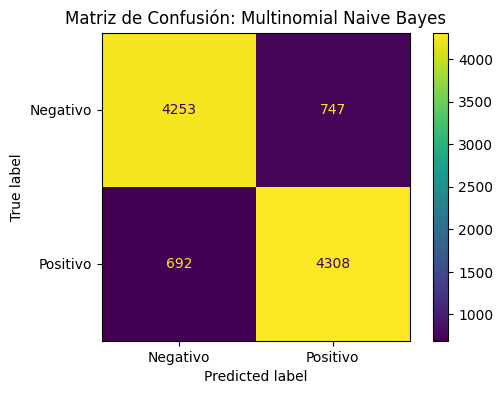


····························································
█████████ EVALUACIÓN DEL MODELO: SVM (Linear SGD) ██████████
····························································

[ MÉTRICAS DE DESEMPEÑO ]
              precision    recall  f1-score   support

Negativo (0)       0.90      0.88      0.89      5000
Positivo (1)       0.88      0.90      0.89      5000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000

Accuracy (Exactitud Global): 0.8895
AUC-ROC (Capacidad de Discriminación): 0.9571


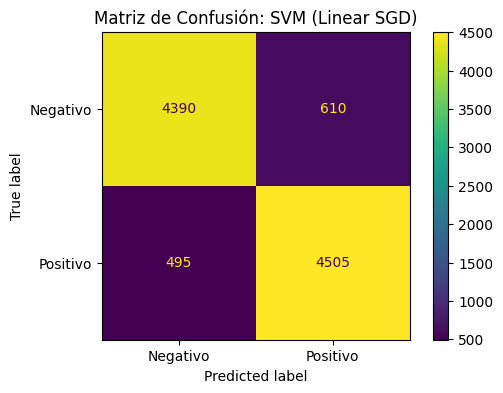


····························································
███████████ EVALUACIÓN DEL MODELO: Random Forest ███████████
····························································

[ MÉTRICAS DE DESEMPEÑO ]
              precision    recall  f1-score   support

Negativo (0)       0.84      0.86      0.85      5000
Positivo (1)       0.86      0.84      0.85      5000

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000

Accuracy (Exactitud Global): 0.8518
AUC-ROC (Capacidad de Discriminación): 0.9313


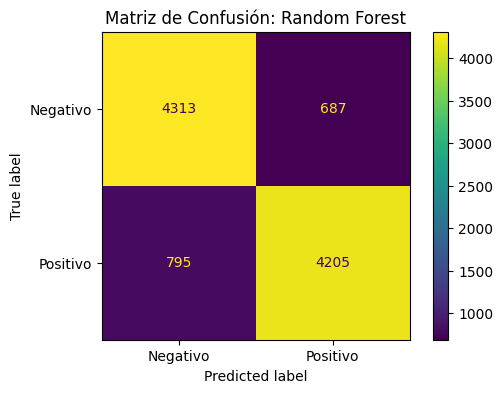


····························································
█████ EVALUACIÓN DEL MODELO: k-Nearest Neighbors (kNN) █████
····························································

[ MÉTRICAS DE DESEMPEÑO ]
              precision    recall  f1-score   support

Negativo (0)       0.79      0.67      0.73      5000
Positivo (1)       0.71      0.82      0.76      5000

    accuracy                           0.74     10000
   macro avg       0.75      0.74      0.74     10000
weighted avg       0.75      0.74      0.74     10000

Accuracy (Exactitud Global): 0.7450
AUC-ROC (Capacidad de Discriminación): 0.8121


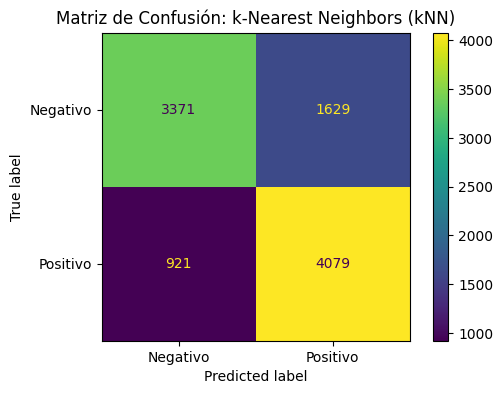


····························································
████████ EVALUACIÓN DEL MODELO: Logistic Regression ████████
····························································

[ MÉTRICAS DE DESEMPEÑO ]
              precision    recall  f1-score   support

Negativo (0)       0.90      0.88      0.89      5000
Positivo (1)       0.88      0.90      0.89      5000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000

Accuracy (Exactitud Global): 0.8908
AUC-ROC (Capacidad de Discriminación): 0.9586


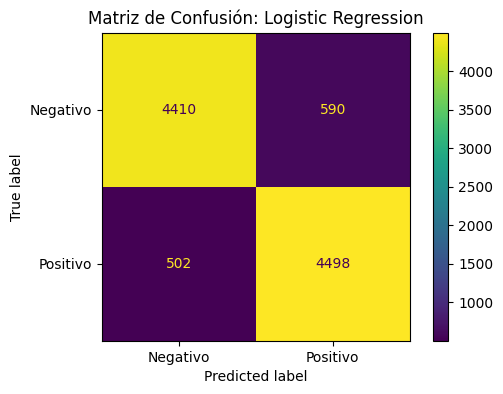

In [8]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import SGDClassifier, LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

# Definimos los modelos con los parámetros sugeridos en los links de la tarea
modelos = [
    (MultinomialNB(), "Multinomial Naive Bayes"),
    # El link pedía usar SGDClassifier con loss para que actúe como SVM
    (SGDClassifier(loss='hinge', random_state=42), "SVM (Linear SGD)"),
    (RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1), "Random Forest"),
    (KNeighborsClassifier(n_neighbors=5), "k-Nearest Neighbors (kNN)"),
    (LogisticRegression(max_iter=1000, random_state=42), "Logistic Regression")
]

# Entrenamos y evaluamos cada uno usando los datos de TF-IDF
for modelo_obj, nombre in modelos:
    evaluar_modelo_clase(modelo_obj, nombre, X_train_tfidf, X_test_tfidf, y_train, y_test)

# **Celda 9: Tabla Bag of Word y TF-IDF**

In [10]:
# TABLAS RESUMEN DE RESULTADOS

import pandas as pd
from sklearn.metrics import precision_recall_fscore_support, accuracy_score, roc_auc_score

# Volvemos a declarar nuestros 5 modelos con la configuración de clase
modelos_lista = [
    (MultinomialNB(), "Naive Bayes"),
    (SGDClassifier(loss='hinge', random_state=42), "SVM"),
    (RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1), "Random Forest"),
    (KNeighborsClassifier(n_neighbors=5), "kNN"),
    (LogisticRegression(max_iter=1000, random_state=42), "Logistic regression")
]

def generar_tabla_metricas(X_train, X_test, y_train, y_test, titulo):
    """
    Entrena los 5 modelos, extrae las métricas matemáticas precisas
    """
    filas_resultados = []

    for modelo_obj, nombre in modelos_lista:
        # 1. Entrenamos el modelo
        modelo_obj.fit(X_train, y_train)

        # 2. Realizamos predicciones
        predicciones = modelo_obj.predict(X_test)

        # 3. Calculamos la probabilidad para el AUC-ROC
        if hasattr(modelo_obj, "predict_proba"):
            probabilidades = modelo_obj.predict_proba(X_test)[:, 1]
        else:
            probabilidades = modelo_obj.decision_function(X_test)

        # 4. Extraemos Precision, Recall y F1 para ambas clases (0 y 1) a la vez
        # La función nos devuelve listas ordenadas: [valor_clase0, valor_clase1]
        precision, recall, f1, _ = precision_recall_fscore_support(y_test, predicciones, labels=[0, 1])

        # 5. Extraemos el Accuracy y el AUC-ROC global
        acc = accuracy_score(y_test, predicciones)
        auc = roc_auc_score(y_test, probabilidades)

        # 6. Acomodamos los números en una lista, redondeados a 4 decimales
        filas_resultados.append([
            nombre,
            round(precision[0], 4), round(recall[0], 4), round(f1[0], 4), # Métricas Clase 0 (Negativa)
            round(precision[1], 4), round(recall[1], 4), round(f1[1], 4), # Métricas Clase 1 (Positiva)
            round(acc, 4), round(auc, 4)                                  # Métricas Globales
        ])

    # 7. Creamos la estructura de doble encabezado (MultiIndex) para que luzca como Excel
    encabezados = pd.MultiIndex.from_tuples([
        ('Modelo', ''),
        ('Clase 0', 'Precision'), ('Clase 0', 'Recall'), ('Clase 0', 'F1-Score'),
        ('Clase 1', 'Precision'), ('Clase 1', 'Recall'), ('Clase 1', 'F1-Score'),
        ('Accuracy', ''), ('AUC-ROC', '')
    ])

    # 8. Convertimos nuestros datos en una tabla (DataFrame)
    df_tabla = pd.DataFrame(filas_resultados, columns=encabezados)

    # Ajustamos el nombre de los modelos para que sea el índice principal a la izquierda
    df_tabla.set_index(('Modelo', ''), inplace=True)
    df_tabla.index.name = 'Modelo'

    # Mostramos la tabla en pantalla
    print(f"\n{'='*70}\n{titulo}\n{'='*70}")
    display(df_tabla)

    return df_tabla

# Generamos y mostramos la tabla alimentándola con los datos de Bag of Words
tabla_bow = generar_tabla_metricas(X_train_bow, X_test_bow, y_train, y_test,
                                   "TABLA 1: MÉTRICAS USANDO BAG OF WORDS (BoW)")

# Generamos y mostramos la tabla alimentándola con los datos de TF-IDF
tabla_tfidf = generar_tabla_metricas(X_train_tfidf, X_test_tfidf, y_train, y_test,
                                     "TABLA 2: MÉTRICAS USANDO TF-IDF")


TABLA 1: MÉTRICAS USANDO BAG OF WORDS (BoW)


Clase 0                    Clase 1                   \
                    Precision  Recall F1-Score Precision  Recall F1-Score   
Modelo                                                                      
Naive Bayes            0.8467  0.8506   0.8486    0.8499  0.8460   0.8480   
SVM                    0.8759  0.8692   0.8725    0.8702  0.8768   0.8735   
Random Forest          0.8480  0.8578   0.8529    0.8561  0.8462   0.8511   
kNN                    0.6233  0.6260   0.6246    0.6243  0.6216   0.6230   
Logistic regression    0.8731  0.8724   0.8727    0.8725  0.8732   0.8729   

                    Accuracy AUC-ROC  
                                      
Modelo                                
Naive Bayes           0.8483  0.9165  
SVM                   0.8730  0.9426  
Random Forest         0.8520  0.9268  
kNN                   0.6238  0.6642  
Logistic regression   0.8728  0.9430


TABLA 2: MÉTRICAS USANDO TF-IDF


Clase 0                    Clase 1                   \
                    Precision  Recall F1-Score Precision  Recall F1-Score   
Modelo                                                                      
Naive Bayes            0.8601  0.8506   0.8553    0.8522  0.8616   0.8569   
SVM                    0.8987  0.8780   0.8882    0.8807  0.9010   0.8908   
Random Forest          0.8444  0.8626   0.8534    0.8596  0.8410   0.8502   
kNN                    0.7854  0.6742   0.7256    0.7146  0.8158   0.7619   
Logistic regression    0.8978  0.8820   0.8898    0.8840  0.8996   0.8918   

                    Accuracy AUC-ROC  
                                      
Modelo                                
Naive Bayes           0.8561  0.9305  
SVM                   0.8895  0.9571  
Random Forest         0.8518  0.9313  
kNN                   0.7450  0.8121  
Logistic regression   0.8908  0.9586

“Se optó por un enfoque de entrenamiento encapsulado dentro de la función de métricas para garantizar la pureza de los resultados. Esto permite comparar de forma objetiva el desempeño de los algoritmos bajo las dos arquitecturas de vectorización (Bag of Words y TF-IDF) sin riesgo de solapamiento de datos en la memoria del entorno.”